In [4]:
# Instalar biblioteca
!pip install ucimlrepo

#**DADOS DE TREINO**

In [7]:
# ==========================================================
# TREINO
# ==========================================================

import pandas as pd
import pickle as p1
import numpy as np

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# ==========================================================
# Carregar dataset digits
# ==========================================================

digits = load_digits()

X = digits.data
y = digits.target

print("Número total de imagens:", len(X))
print("Número de features:", len(X[0]))

# ==========================================================
# Redução de dimensão PCA
# ==========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# ==========================================================
# Separar treino e teste
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_pca,
    y,
    test_size=0.33,
    random_state=42,
    stratify=y
)

# ==========================================================
# Treinar KNN
# ==========================================================

modelo = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance"
)

modelo.fit(X_train, y_train)

# ==========================================================
# Guardar modelo
# ==========================================================

with open("digits_knn.pkl", "wb") as f:
    p1.dump(modelo, f)

print("Modelo guardado.")

# ==========================================================
# Guardar PCA
# ==========================================================

with open("digits_pca.pkl", "wb") as f:
    p1.dump(pca, f)

print("PCA guardado.")

# ==========================================================
# Guardar dados de teste
# ==========================================================

dados_teste = [X_test, y_test]

with open("digits_test.pkl", "wb") as f:
    p1.dump(dados_teste, f)

print("Dados de teste guardados.")

Número total de imagens: 1797
Número de features: 64
Modelo guardado.
PCA guardado.
Dados de teste guardados.


#**DADOS DE TESTE**

Accuracy: 0.6414141414141414


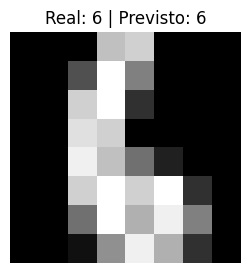

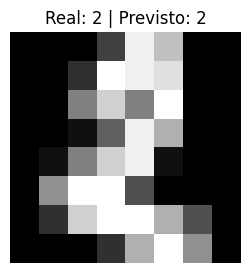

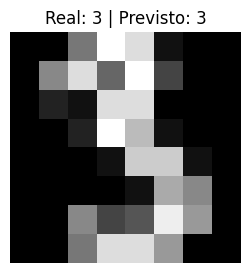

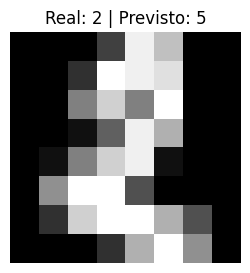

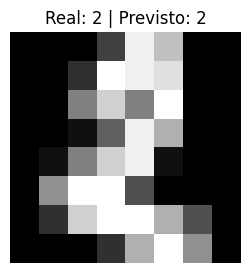

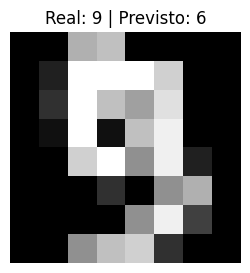

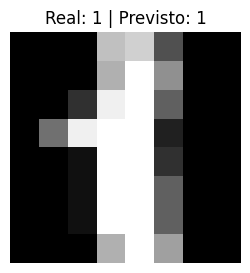

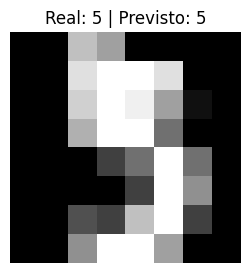

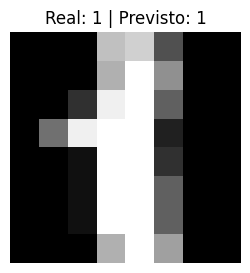

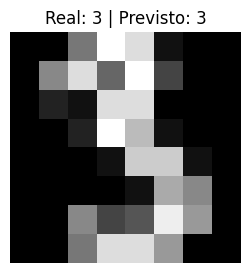

In [8]:
# ==========================================================
# TESTE
# ==========================================================

import pickle as p1
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.metrics import accuracy_score

# ==========================================================
# Carregar dados
# ==========================================================

with open("digits_knn.pkl", "rb") as f:
    modelo = p1.load(f)

with open("digits_test.pkl", "rb") as f:
    X_test, y_test = p1.load(f)

with open("digits_pca.pkl", "rb") as f:
    pca = p1.load(f)

# ==========================================================
# Dataset original (para mostrar imagens)
# ==========================================================

digits = load_digits()

X_original = digits.data
imagens = digits.images
targets = digits.target

# ==========================================================
# Previsões
# ==========================================================

y_pred = modelo.predict(X_test)

# ==========================================================
# Accuracy
# ==========================================================

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

# ==========================================================
# Mostrar alguns exemplos
# ==========================================================

for i in range(10):

    pred = y_pred[i]
    real = y_test[i]

    # Procurar imagem correspondente
    indice = np.where(targets == real)[0][0]

    imagem = imagens[indice]

    plt.figure(figsize=(3,3))

    plt.imshow(imagem, cmap="gray")

    plt.title(f"Real: {real} | Previsto: {pred}")

    plt.axis("off")

    plt.show()

#**DADOS DE PREVISÃO**

Escolha índice do dígito: 3


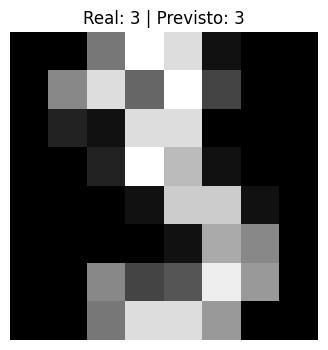

Valor previsto: 3
Valor real: 3


In [9]:
# ==========================================================
# PREDIÇÃO
# ==========================================================

import pickle as p1
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

# ==========================================================
# Carregar modelo e PCA
# ==========================================================

with open("digits_knn.pkl", "rb") as f:
    modelo = p1.load(f)

with open("digits_pca.pkl", "rb") as f:
    pca = p1.load(f)

# ==========================================================
# Dataset
# ==========================================================

digits = load_digits()

X = digits.data
y = digits.target
images = digits.images

# ==========================================================
# Escolher índice
# ==========================================================

n = int(input("Escolha índice do dígito: "))

# ==========================================================
# Dados do dígito
# ==========================================================

imagem_original = images[n]

x_original = X[n]

# Aplicar PCA
x_pca = pca.transform([x_original])

# ==========================================================
# Predição
# ==========================================================

pred = modelo.predict(x_pca)

# ==========================================================
# Mostrar imagem
# ==========================================================

plt.figure(figsize=(4,4))

plt.imshow(imagem_original, cmap="gray")

plt.title(
    f"Real: {y[n]} | Previsto: {pred[0]}"
)

plt.axis("off")

plt.show()

print("Valor previsto:", pred[0])
print("Valor real:", y[n])